In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

data = pd.read_csv("updated_car_data.csv")
data.head()

,Brand,Parent,Country,Luxury
0,Acura,Honda Motor Company,Japan,Yes
1,Alfa Romeo,Stellantis,Italy,Yes
2,Audi,Volkswagen Group,Germany,Yes
3,BMW,BMW Group,Germany,Yes
4,Bentley,Volkswagen Group,UK,Yes


In [5]:
print(data.shape)
print(data.columns)

(54, 4)
Index(['Brand', 'Parent', 'Country', 'Luxury'], dtype='object')


In [7]:
# Bipartite Graph:
B = nx.Graph()

for i in range(len(data)):
    parent = data.loc[i, "Parent"]
    brand = data.loc[i, "Brand"]
    country = data.loc[i, "Country"]
    luxury = data.loc[i, "Luxury"]

    B.add_node(parent, node_type="parent")
    B.add_node(brand, node_type="brand", country=country, luxury=luxury)
    B.add_edge(parent, brand)

print("Number of nodes:", B.number_of_nodes())
print("Number of edges:", B.number_of_edges())

Number of nodes: 72
Number of edges: 54


In [9]:
parent_nodes = []
brand_nodes = []

for node, info in B.nodes(data=True):
    if info["node_type"] == "parent":
        parent_nodes.append(node)
    else:
        brand_nodes.append(node)

print("Parent companies:", parent_nodes)
print("Brands:", brand_nodes)

Parent companies: ['Honda Motor Company', 'Stellantis', 'Volkswagen Group', 'BMW Group', 'General Motors', 'Ford Motor Company', 'Hyundai Motor Group', 'Tata Motors', 'Nissan Motor Company', 'Toyota Motor Corporation', 'Mazda Motor Corporation', 'Mitsubishi Motors', 'Subaru Corporation', 'Tesla Inc', 'Mercedes-Benz Group', 'Geely', 'Ferrari N.V', 'Suzuki Motor Corporation']
Brands: ['Acura', 'Alfa Romeo', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'Fiat', 'Ford', 'GMC', 'Genesis', 'Honda', 'Hyundai', 'Jaguar', 'Infiniti', 'Jeep', 'Kia', 'Lexus', 'Lamborghini', 'Lincoln', 'Maserati', 'Mazda', 'Mer', 'Mini', 'Mitsubishi', 'Nissan', 'Porsche', 'RAM', 'Range Rover', 'Rolls-Royce', 'Subaru', 'Tesla', 'Volkswagen', 'Alpina', 'Maybach', 'Mercedes-Benz', 'Renault', 'Volvo ', 'Lotus', 'Toyota', 'Ioniq', 'Land Rover', 'Ferrari ', 'Mercury', 'Chevrolet Corvette', 'Ford Mustang', 'Pontiac', 'Suzuki', 'Saturn', 'Isuzu']


In [11]:
# Finding Biggest Hubs

parent_degree = {}

for parent in parent_nodes:
    parent_degree[parent] = B.degree(parent)

print("Parent company degrees:")
for parent in parent_degree:
    print(parent, ":", parent_degree[parent])

max_parent = max(parent_degree, key=parent_degree.get)

print("\nLargest parent company:", max_parent)
print("Number of brands:", parent_degree[max_parent])

Parent company degrees:
Honda Motor Company : 2
Stellantis : 7
Volkswagen Group : 6
BMW Group : 4
General Motors : 7
Ford Motor Company : 5
Hyundai Motor Group : 4
Tata Motors : 3
Nissan Motor Company : 3
Toyota Motor Corporation : 2
Mazda Motor Corporation : 1
Mitsubishi Motors : 2
Subaru Corporation : 1
Tesla Inc : 1
Mercedes-Benz Group : 2
Geely : 2
Ferrari N.V : 1
Suzuki Motor Corporation : 1

Largest parent company: Stellantis
Number of brands: 7


In [13]:
sorted_parents = sorted(parent_degree.items(), key=lambda x: x[1], reverse=True)

for item in sorted_parents:
    print(item[0], ":", item[1])

Stellantis : 7
General Motors : 7
Volkswagen Group : 6
Ford Motor Company : 5
BMW Group : 4
Hyundai Motor Group : 4
Tata Motors : 3
Nissan Motor Company : 3
Honda Motor Company : 2
Toyota Motor Corporation : 2
Mitsubishi Motors : 2
Mercedes-Benz Group : 2
Geely : 2
Mazda Motor Corporation : 1
Subaru Corporation : 1
Tesla Inc : 1
Ferrari N.V : 1
Suzuki Motor Corporation : 1


                      Parent  Degree
0                 Stellantis       7
1             General Motors       7
2           Volkswagen Group       6
3         Ford Motor Company       5
4                  BMW Group       4
5        Hyundai Motor Group       4
6                Tata Motors       3
7       Nissan Motor Company       3
8        Honda Motor Company       2
9   Toyota Motor Corporation       2
10         Mitsubishi Motors       2
11       Mercedes-Benz Group       2
12                     Geely       2
13   Mazda Motor Corporation       1
14        Subaru Corporation       1
15                 Tesla Inc       1
16               Ferrari N.V       1
17  Suzuki Motor Corporation       1


<Figure size 1000x500 with 0 Axes>

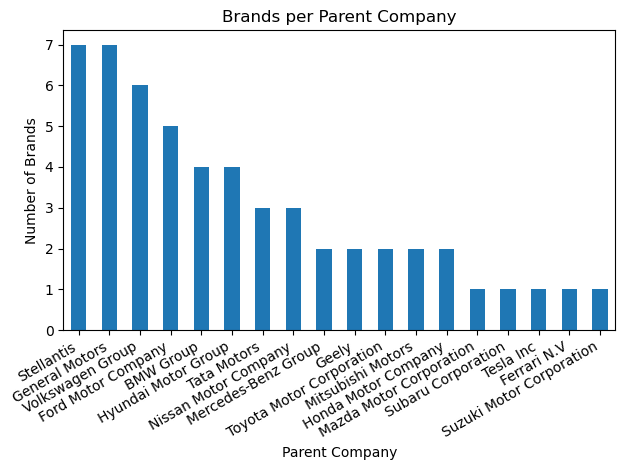

In [15]:

import pandas as pd
parent_table = pd.DataFrame(sorted_parents, columns=["Parent", "Degree"])

print(parent_table)

plt.figure(figsize=(10,5))

parent_table = parent_table.sort_values(by="Degree", ascending=False)
parent_table.plot(x="Parent", y="Degree", kind="bar", legend=False)

plt.xticks(rotation=30, ha="right")
plt.title("Brands per Parent Company")
plt.ylabel("Number of Brands")
plt.xlabel("Parent Company")

plt.tight_layout()
plt.show()

In [21]:
degree_centrality = nx.degree_centrality(G)

for brand in degree_centrality:
    print(brand, ":", degree_centrality[brand])

Acura : 0.018867924528301886
Alfa Romeo : 0.11320754716981132
Audi : 0.09433962264150943
BMW : 0.05660377358490566
Bentley : 0.09433962264150943
Bugatti : 0.09433962264150943
Buick : 0.11320754716981132
Cadillac : 0.11320754716981132
Chevrolet : 0.11320754716981132
Chrysler : 0.11320754716981132
Dodge : 0.11320754716981132
Fiat : 0.11320754716981132
Ford : 0.07547169811320754
GMC : 0.11320754716981132
Genesis : 0.05660377358490566
Honda : 0.018867924528301886
Hyundai : 0.05660377358490566
Jaguar : 0.03773584905660377
Infiniti : 0.03773584905660377
Jeep : 0.11320754716981132
Kia : 0.05660377358490566
Lexus : 0.018867924528301886
Lamborghini : 0.09433962264150943
Lincoln : 0.07547169811320754
Maserati : 0.11320754716981132
Mazda : 0.0
Mer : 0.07547169811320754
Mini : 0.05660377358490566
Mitsubishi : 0.018867924528301886
Nissan : 0.03773584905660377
Porsche : 0.09433962264150943
RAM : 0.11320754716981132
Range Rover : 0.03773584905660377
Rolls-Royce : 0.05660377358490566
Subaru : 0.0
Tesl

In [17]:
G = nx.bipartite.projected_graph(B, brand_nodes)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 54
Number of edges: 90


In [19]:
# create brand_degree from projected graph G
brand_degree = {}

for brand in G.nodes():
    brand_degree[brand] = G.degree(brand)

sorted_brands = sorted(brand_degree.items(), key=lambda x: x[1], reverse=True)

for item in sorted_brands:
    print(item[0], ":", item[1])

brand_table = pd.DataFrame(sorted_brands, columns=["Brand", "Degree"])
print(brand_table)

Alfa Romeo : 6
Buick : 6
Cadillac : 6
Chevrolet : 6
Chrysler : 6
Dodge : 6
Fiat : 6
GMC : 6
Jeep : 6
Maserati : 6
RAM : 6
Chevrolet Corvette : 6
Pontiac : 6
Saturn : 6
Audi : 5
Bentley : 5
Bugatti : 5
Lamborghini : 5
Porsche : 5
Volkswagen : 5
Ford : 4
Lincoln : 4
Mer : 4
Mercury : 4
Ford Mustang : 4
BMW : 3
Genesis : 3
Hyundai : 3
Kia : 3
Mini : 3
Rolls-Royce : 3
Alpina : 3
Ioniq : 3
Jaguar : 2
Infiniti : 2
Nissan : 2
Range Rover : 2
Renault : 2
Land Rover : 2
Acura : 1
Honda : 1
Lexus : 1
Mitsubishi : 1
Maybach : 1
Mercedes-Benz : 1
Volvo  : 1
Lotus : 1
Toyota : 1
Isuzu : 1
Mazda : 0
Subaru : 0
Tesla : 0
Ferrari  : 0
Suzuki : 0
                 Brand  Degree
0           Alfa Romeo       6
1                Buick       6
2             Cadillac       6
3            Chevrolet       6
4             Chrysler       6
5                Dodge       6
6                 Fiat       6
7                  GMC       6
8                 Jeep       6
9             Maserati       6
10                 RA

In [37]:
avg_degree = sum(d for _, d in G.degree()) / G.number_of_nodes()
print(avg_degree)

3.3333333333333335


In [23]:
betweenness = nx.betweenness_centrality(G)

for brand in betweenness:
    print(brand, ":", betweenness[brand])

Acura : 0.0
Alfa Romeo : 0.0
Audi : 0.0
BMW : 0.0
Bentley : 0.0
Bugatti : 0.0
Buick : 0.0
Cadillac : 0.0
Chevrolet : 0.0
Chrysler : 0.0
Dodge : 0.0
Fiat : 0.0
Ford : 0.0
GMC : 0.0
Genesis : 0.0
Honda : 0.0
Hyundai : 0.0
Jaguar : 0.0
Infiniti : 0.0
Jeep : 0.0
Kia : 0.0
Lexus : 0.0
Lamborghini : 0.0
Lincoln : 0.0
Maserati : 0.0
Mazda : 0.0
Mer : 0.0
Mini : 0.0
Mitsubishi : 0.0
Nissan : 0.0
Porsche : 0.0
RAM : 0.0
Range Rover : 0.0
Rolls-Royce : 0.0
Subaru : 0.0
Tesla : 0.0
Volkswagen : 0.0
Alpina : 0.0
Maybach : 0.0
Mercedes-Benz : 0.0
Renault : 0.0
Volvo  : 0.0
Lotus : 0.0
Toyota : 0.0
Ioniq : 0.0
Land Rover : 0.0
Ferrari  : 0.0
Mercury : 0.0
Chevrolet Corvette : 0.0
Ford Mustang : 0.0
Pontiac : 0.0
Suzuki : 0.0
Saturn : 0.0
Isuzu : 0.0


In [25]:
clustering = nx.clustering(G)

for brand in clustering:
    print(brand, ":", clustering[brand])

Acura : 0
Alfa Romeo : 1.0
Audi : 1.0
BMW : 1.0
Bentley : 1.0
Bugatti : 1.0
Buick : 1.0
Cadillac : 1.0
Chevrolet : 1.0
Chrysler : 1.0
Dodge : 1.0
Fiat : 1.0
Ford : 1.0
GMC : 1.0
Genesis : 1.0
Honda : 0
Hyundai : 1.0
Jaguar : 1.0
Infiniti : 1.0
Jeep : 1.0
Kia : 1.0
Lexus : 0
Lamborghini : 1.0
Lincoln : 1.0
Maserati : 1.0
Mazda : 0
Mer : 1.0
Mini : 1.0
Mitsubishi : 0
Nissan : 1.0
Porsche : 1.0
RAM : 1.0
Range Rover : 1.0
Rolls-Royce : 1.0
Subaru : 0
Tesla : 0
Volkswagen : 1.0
Alpina : 1.0
Maybach : 0
Mercedes-Benz : 0
Renault : 1.0
Volvo  : 0
Lotus : 0
Toyota : 0
Ioniq : 1.0
Land Rover : 1.0
Ferrari  : 0
Mercury : 1.0
Chevrolet Corvette : 1.0
Ford Mustang : 1.0
Pontiac : 1.0
Suzuki : 0
Saturn : 1.0
Isuzu : 0


In [39]:
results = pd.DataFrame({
    "Brand": list(G.nodes()),
    "Degree Centrality": [degree_centrality[brand] for brand in G.nodes()],
    "Betweenness Centrality": [betweenness[brand] for brand in G.nodes()],
    "Clustering Coefficient": [clustering[brand] for brand in G.nodes()]
})

results = results.sort_values(by="Degree Centrality", ascending=False)

print(results)
print("Avg clustering:", nx.average_clustering(G))

                 Brand  Degree Centrality  Betweenness Centrality  \
48  Chevrolet Corvette           0.113208                     0.0   
9             Chrysler           0.113208                     0.0   
50             Pontiac           0.113208                     0.0   
31                 RAM           0.113208                     0.0   
19                Jeep           0.113208                     0.0   
52              Saturn           0.113208                     0.0   
13                 GMC           0.113208                     0.0   
11                Fiat           0.113208                     0.0   
10               Dodge           0.113208                     0.0   
24            Maserati           0.113208                     0.0   
8            Chevrolet           0.113208                     0.0   
7             Cadillac           0.113208                     0.0   
6                Buick           0.113208                     0.0   
1           Alfa Romeo           0

In [27]:
nx.write_gexf(G, "car_brands_projected.gexf")

In [29]:
B_dummy = B.copy()

B_dummy.add_node("Auto Industry", node_type="root")

for parent in parent_nodes:
    B_dummy.add_edge("Auto Industry", parent)

print("Original components:", nx.number_connected_components(B))
print("With dummy root:", nx.number_connected_components(B_dummy))

Original components: 18
With dummy root: 1


In [31]:
nx.write_gexf(B_dummy, "car_brands_bipartite_dummy_root_pic.gexf")

In [33]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Components:", nx.number_connected_components(G))
print("Avg clustering:", nx.average_clustering(G))
print("Largest parent:", max_parent)
print("Brands owned:", parent_degree[max_parent])

Nodes: 54
Edges: 90
Components: 18
Avg clustering: 0.7222222222222222
Largest parent: Stellantis
Brands owned: 7
